<a href="https://colab.research.google.com/github/sadhika-tech/deep-learning-lab/blob/main/Lab%207/Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import time, numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from skimage.metrics import structural_similarity as ssim
from sklearn.decomposition import PCA
from scipy.stats import norm

SEED = 42
keras.utils.set_random_seed(SEED)
EPOCHS, BATCH = 20, 128
N_TRAIN, N_TEST = 10000, 2000
pd.set_option('display.float_format', lambda v: f'{v:.5f}')

(x_tr, y_tr), (x_te, y_te) = keras.datasets.mnist.load_data()
x_train = (x_tr[:N_TRAIN] / 255.).astype('float32')[..., None]
y_train = y_tr[:N_TRAIN]
x_test  = (x_te[:N_TEST]  / 255.).astype('float32')[..., None]
y_test  = y_te[:N_TEST]
x_train_f, x_test_f = x_train.reshape(-1, 784), x_test.reshape(-1, 784)
print(x_train.shape, x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(10000, 28, 28, 1) (2000, 28, 28, 1)


In [2]:
# ---------- Helpers ----------
def get_metrics(x, xh):
    x = np.asarray(x).reshape(-1, 28, 28); xh = np.asarray(xh).reshape(-1, 28, 28)
    mse = float(np.mean((x - xh) ** 2)); mae = float(np.mean(np.abs(x - xh)))
    s = float(np.mean([ssim(a, b, data_range=1.0) for a, b in zip(x, xh)]))
    return mse, mae, s

def per_image_mse(x, xh):
    return np.mean((np.asarray(x).reshape(len(x), -1) - np.asarray(xh).reshape(len(xh), -1)) ** 2, axis=1)

def fit_ae(model, x_in, x_out, epochs=EPOCHS, verbose=2, lr=1e-3):
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='binary_crossentropy')
    t = time.time()
    h = model.fit(x_in, x_out, epochs=epochs, batch_size=BATCH, validation_split=0.1,
                  shuffle=True, verbose=verbose)
    return h, time.time() - t

def show_grid(rows, names, n=10, cmaps=None, title=None):
    fig, ax = plt.subplots(len(rows), n, figsize=(n * 1.2, len(rows) * 1.4))
    ax = np.atleast_2d(ax)
    for r, (imgs, nm) in enumerate(zip(rows, names)):
        for c in range(n):
            ax[r, c].imshow(np.asarray(imgs[c]).reshape(28, 28),
                            cmap=(cmaps[r] if cmaps else 'gray'), vmin=0, vmax=1)
            ax[r, c].axis('off')
        ax[r, 0].text(-0.15, 0.5, nm, transform=ax[r, 0].transAxes, ha='right', va='center', fontsize=10)
    if title: fig.suptitle(title)
    plt.subplots_adjust(left=0.12)
    plt.show()

def tile(imgs, r, c):
    imgs = np.asarray(imgs).reshape(-1, 28, 28)[:r * c]
    return imgs.reshape(r, c, 28, 28).transpose(0, 2, 1, 3).reshape(r * 28, c * 28)

def plot_history(h, title, ylabel='Reconstruction loss (BCE)'):
    plt.figure(figsize=(6, 4))
    plt.plot(h.history['loss'], label='Training loss')
    plt.plot(h.history['val_loss'], label='Validation loss')
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=.3)
    plt.show()

def error_distribution(x, xh, name, top=5):
    e = per_image_mse(x, xh)
    print(f'{name}: mean={e.mean():.5f} median={np.median(e):.5f} std={e.std():.5f} '
          f'95th pct={np.percentile(e, 95):.5f} max={e.max():.5f}')
    plt.figure(figsize=(6, 4))
    plt.hist(e, bins=50, color='steelblue', edgecolor='k')
    plt.axvline(e.mean(), color='r', ls='--', label='mean')
    plt.axvline(np.percentile(e, 95), color='orange', ls='--', label='95th pct')
    plt.xlabel('Per-image reconstruction error $e_i$ (MSE)')
    plt.ylabel('Number of test images')
    plt.title(f'Reconstruction-error distribution – {name}')
    plt.legend()
    plt.show()
    idx = np.argsort(e)[-top:][::-1]
    print('Highest-error samples (index, label, error):', [(int(i), int(y_test[i]), round(float(e[i]), 5)) for i in idx])
    show_grid([x[idx], xh[idx], np.abs(x[idx].reshape(top, -1) - xh[idx].reshape(top, -1))],
              ['Original', 'Reconstruction', 'Abs. error'], n=top, cmaps=['gray', 'gray', 'magma'],
              title=f'Top-{top} high-error images – {name}')

results = {}

In [3]:
def build_fc_ae(d=16):
    inp = keras.Input((784,))
    x = layers.Dense(128, activation='relu')(inp)
    x = layers.Dense(32, activation='relu')(x)
    z = layers.Dense(d, name='latent')(x)
    x = layers.Dense(32, activation='relu')(z)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(784, activation='sigmoid')(x)
    return keras.Model(inp, out, name=f'fc_ae_{d}')

fc = build_fc_ae(16)
fc.summary()
h_fc, t_fc = fit_ae(fc, x_train_f, x_train_f)

Model: "fc_ae_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
71/71 - 3s - 36ms/step - loss: 0.3516 - val_loss: 0.2606
Epoch 2/20
71/71 - 0s - 6ms/step - loss: 0.2299 - val_loss: 0.2075
Epoch 3/20
71/71 - 0s - 6ms/step - loss: 0.1924 - val_loss: 0.1845
Epoch 4/20
71/71 - 0s - 7ms/step - loss: 0.1720 - val_loss: 0.1697
Epoch 5/20
71/71 - 0s - 6ms/step - loss: 0.1612 - val_loss: 0.1615
Epoch 6/20
71/71 - 1s - 7ms/step - loss: 0.1529 - val_loss: 0.1545
Epoch 7/20
71/71 - 0s - 7ms/step - loss: 0.1460 - val_loss: 0.1488
Epoch 8/20
71/71 - 0s - 6ms/step - loss: 0.1410 - val_loss: 0.1448
Epoch 9/20
71/71 - 0s - 6ms/step - loss: 0.1375 - val_loss: 0.1420
Epoch 10/20
71/71 - 0s - 7ms/step - loss: 0.1348 - val_loss: 0.1398
Epoch 11/20
71/71 - 1s - 8ms/step - loss: 0.1326 - val_loss: 0.1381
Epoch 12/20
71/71 - 1s - 7ms/step - loss: 0.1308 - val_loss: 0.1365
Epoch 13/20
71/71 - 0s - 6ms/step - loss: 0.1291 - val_loss: 0.1350
Epoch 14/20
71/71 - 0s - 6ms/step - loss: 0.1275 - val_loss: 0.1335
Epoch 15/20
71/71 - 1s - 11ms/step - loss: 0.1258 - val_

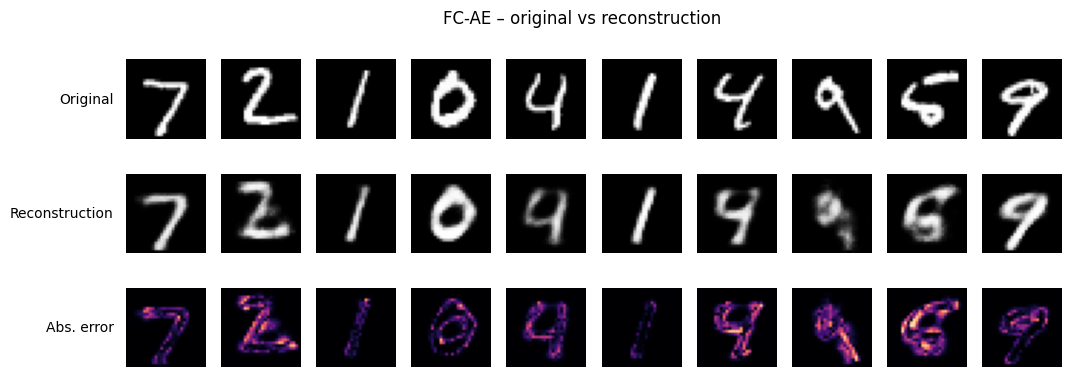

In [5]:
xh_fc = fc.predict(x_test_f, verbose=0)
show_grid([x_test_f[:10], xh_fc[:10], np.abs(x_test_f[:10] - xh_fc[:10])],
          ['Original', 'Reconstruction', 'Abs. error'], cmaps=['gray', 'gray', 'magma'],
          title='FC-AE – original vs reconstruction')


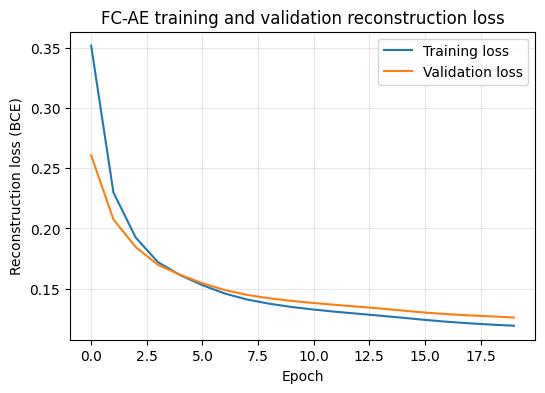

In [6]:
plot_history(h_fc, 'FC-AE training and validation reconstruction loss')


In [7]:
m = get_metrics(x_test_f, xh_fc)
print(pd.DataFrame({'Metric': ['Test MSE', 'Test MAE', 'Mean SSIM'], 'Value': m}).to_string(index=False))
results['FC Autoencoder'] = (*m, fc.count_params(), t_fc)

   Metric   Value
 Test MSE 0.02043
 Test MAE 0.05521
Mean SSIM 0.75860


Model: "cae_upsample"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
71/71 - 20s - 276ms/step - loss: 0.2618 - val_loss: 0.1141
Epoch 2/20
71/71 - 20s - 277ms/step - loss: 0.0958 - val_loss: 0.0901
Epoch 3/20
71/71 - 16s - 231ms/step - loss: 0.0848 - val_loss: 0.0839
Epoch 4/20
71/71 - 14s - 202ms/step - loss: 0.0801 - val_loss: 0.0801
Epoch 5/20
71/71 - 21s - 290ms/step - loss: 0.0773 - val_loss: 0.0779
Epoch 6/20
71/71 - 20s - 286ms/step - loss: 0.0753 - val_loss: 0.0763
Epoch 7/20
71/71 - 14s - 204ms/step - loss: 0.0741 - val_loss: 0.0751
Epoch 8/20
71/71 - 21s - 294ms/step - loss: 0.0731 - val_loss: 0.0751
Epoch 9/20
71/71 - 21s - 298ms/step - loss: 0.0724 - val_loss: 0.0740
Epoch 10/20
71/71 - 15s - 208ms/step - loss: 0.0718 - val_loss: 0.0728
Epoch 11/20
71/71 - 14s - 202ms/step - loss: 0.0712 - val_loss: 0.0723
Epoch 12/20
71/71 - 21s - 291ms/step - loss: 0.0708 - val_loss: 0.0718
Epoch 13/20
71/71 - 15s - 208ms/step - loss: 0.0704 - val_loss: 0.0715
Epoch 14/20
71/71 - 15s - 210ms/step - loss: 0.0700 - val_loss: 0.0711
Epoch 15/20
71/

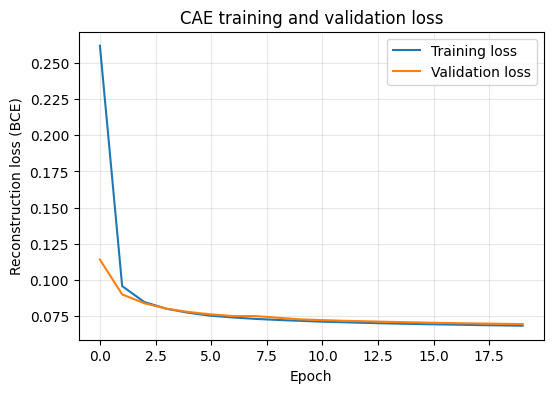

In [8]:
def build_cae(decoder='upsample'):
    inp = keras.Input((28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    if decoder == 'upsample':
        x = layers.UpSampling2D(2)(x)
        x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
        x = layers.UpSampling2D(2)(x)
        out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)
    else:
        x = layers.Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(x)
        out = layers.Conv2DTranspose(1, 3, strides=2, activation='sigmoid', padding='same')(x)
    return keras.Model(inp, out, name=f'cae_{decoder}')

cae = build_cae()
cae.summary()
h_cae, t_cae = fit_ae(cae, x_train, x_train)
xh_cae = cae.predict(x_test, verbose=0)
plot_history(h_cae, 'CAE training and validation loss')

m_cae = get_metrics(x_test, xh_cae)
results['Conv. Autoencoder'] = (*m_cae, cae.count_params(), t_cae)

             Model     MSE     MAE    SSIM  Parameters
Fully Connected AE 0.02043 0.05521 0.75860      211040
  Convolutional AE 0.00262 0.01510 0.97372       74497


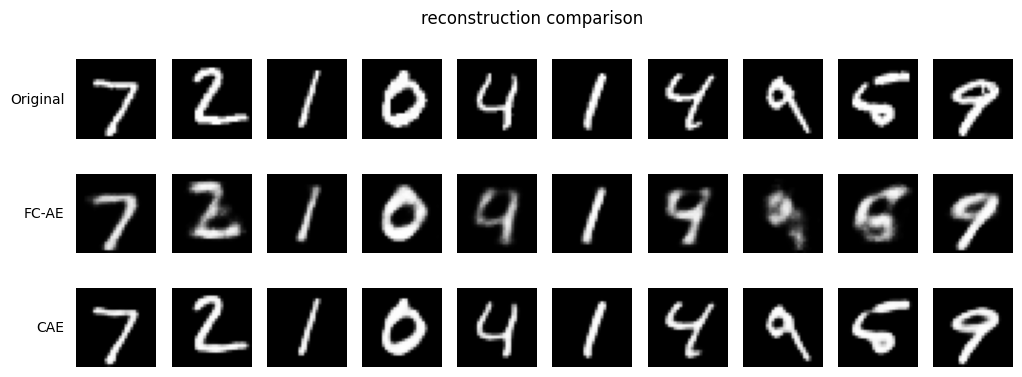

In [9]:
print(pd.DataFrame({'Model': ['Fully Connected AE', 'Convolutional AE'],
                    'MSE': [m[0], m_cae[0]], 'MAE': [m[1], m_cae[1]], 'SSIM': [m[2], m_cae[2]],
                    'Parameters': [fc.count_params(), cae.count_params()]}).to_string(index=False))
show_grid([x_test[:10], xh_fc[:10], xh_cae[:10]], ['Original', 'FC-AE', 'CAE'],
          title='reconstruction comparison')

Epoch 1/20
71/71 - 16s - 231ms/step - loss: 0.2648 - val_loss: 0.1274
Epoch 2/20
71/71 - 21s - 299ms/step - loss: 0.1099 - val_loss: 0.1021
Epoch 3/20
71/71 - 37s - 520ms/step - loss: 0.0955 - val_loss: 0.0938
Epoch 4/20
71/71 - 21s - 292ms/step - loss: 0.0903 - val_loss: 0.0901
Epoch 5/20
71/71 - 18s - 248ms/step - loss: 0.0867 - val_loss: 0.0877
Epoch 6/20
71/71 - 16s - 220ms/step - loss: 0.0848 - val_loss: 0.0856
Epoch 7/20
71/71 - 15s - 213ms/step - loss: 0.0831 - val_loss: 0.0840
Epoch 8/20
71/71 - 21s - 290ms/step - loss: 0.0818 - val_loss: 0.0829
Epoch 9/20
71/71 - 20s - 285ms/step - loss: 0.0808 - val_loss: 0.0821
Epoch 10/20
71/71 - 21s - 301ms/step - loss: 0.0799 - val_loss: 0.0815
Epoch 11/20
71/71 - 19s - 271ms/step - loss: 0.0792 - val_loss: 0.0808
Epoch 12/20
71/71 - 15s - 208ms/step - loss: 0.0787 - val_loss: 0.0801
Epoch 13/20
71/71 - 15s - 208ms/step - loss: 0.0782 - val_loss: 0.0797
Epoch 14/20
71/71 - 20s - 288ms/step - loss: 0.0777 - val_loss: 0.0793
Epoch 15/20
71/

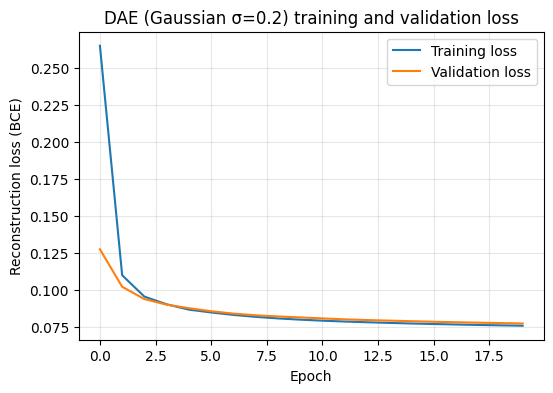

In [10]:
def add_gaussian(x, sigma, seed=0):
    rng = np.random.default_rng(seed)
    return np.clip(x + rng.normal(0, sigma, x.shape), 0, 1).astype('float32')

def add_sp(x, p, seed=0):
    rng = np.random.default_rng(seed)
    r = rng.random(x.shape)
    y = x.copy()
    y[r < p / 2] = 0.0
    y[(r >= p / 2) & (r < p)] = 1.0
    return y.astype('float32')

def train_dae(add_fn, level, verbose=0):
    model = build_cae()
    h, t = fit_ae(model, add_fn(x_train, level, seed=1), x_train, verbose=verbose)
    return model, h, t

def sweep(model, add_fn, levels):
    rows = []
    for l in levels:
        xn = add_fn(x_test, l, seed=123)
        xd = model.predict(xn, verbose=0)
        mn, an, sn = get_metrics(x_test, xn)
        md, ad, sd = get_metrics(x_test, xd)
        rows.append({'Noise Level': l, 'MSE': md, 'MAE': ad, 'SSIM': sd,
                     'Noisy-input MSE': mn, 'Noisy-input MAE': an, 'Noisy-input SSIM': sn})
    return pd.DataFrame(rows)

def plot_sweep(df, title, xlabel):
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    for a, k in zip(ax, ['MSE', 'MAE', 'SSIM']):
        a.plot(df['Noise Level'], df[k], 'o-', label='Denoised')
        a.plot(df['Noise Level'], df[f'Noisy-input {k}'], 's--', label='Noisy input')
        a.set_xlabel(xlabel)
        a.set_ylabel(k)
        a.set_title(k)
        a.grid(alpha=.3)
        a.legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

dae_g, h_dg, t_dae = train_dae(add_gaussian, 0.2, verbose=2)      # Gaussian sigma = 0.2
dae_sp, h_dsp, _   = train_dae(add_sp, 0.10)                       # Salt & pepper p = 0.10
plot_history(h_dg, 'DAE (Gaussian σ=0.2) training and validation loss')

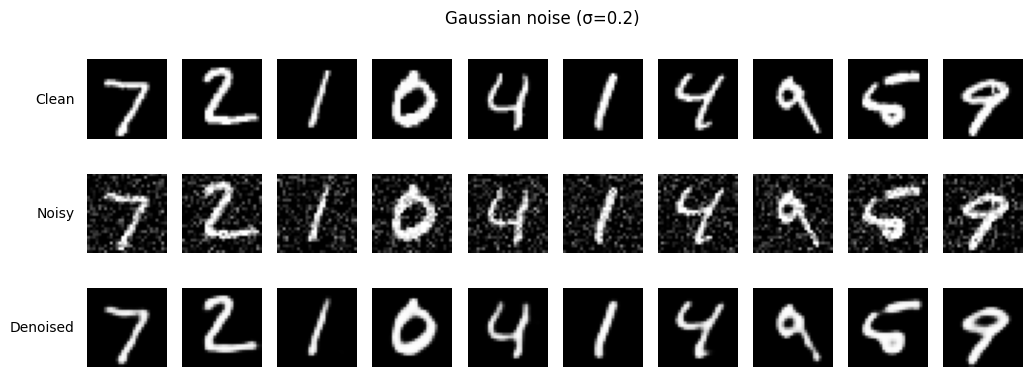

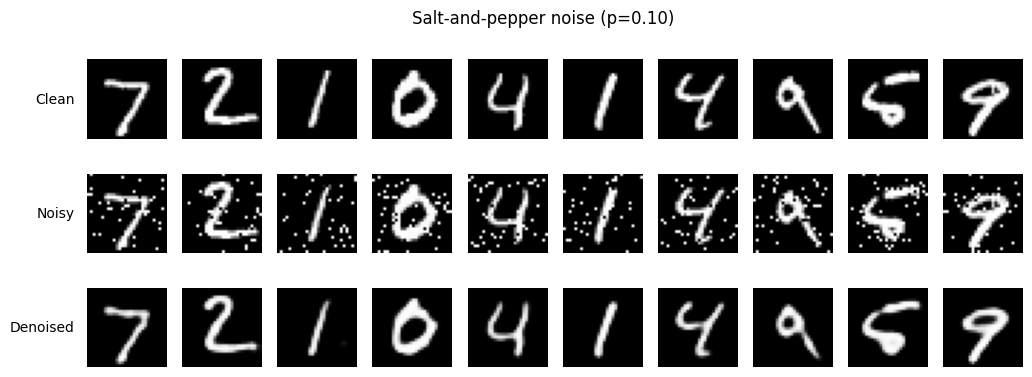

In [11]:
xn = add_gaussian(x_test, 0.2, seed=123)
show_grid([x_test[:10], xn[:10], dae_g.predict(xn[:10], verbose=0)], ['Clean', 'Noisy', 'Denoised'],
          title='Gaussian noise (σ=0.2)')
xn = add_sp(x_test, 0.10, seed=123)
show_grid([x_test[:10], xn[:10], dae_sp.predict(xn[:10], verbose=0)], ['Clean', 'Noisy', 'Denoised'],
          title='Salt-and-pepper noise (p=0.10)')

Gaussian noise (DAE trained at σ=0.2)
 Noise Level     MSE     MAE    SSIM  Noisy-input MSE  Noisy-input MAE  Noisy-input SSIM
     0.10000 0.00380 0.01822 0.95845          0.00543          0.04408           0.67892
     0.20000 0.00479 0.02164 0.94371          0.02122          0.08664           0.59385
     0.30000 0.00722 0.02964 0.87211          0.04666          0.12808           0.50938

Salt-and-pepper noise (DAE trained at p=0.10)
 Noise Level     MSE     MAE    SSIM  Noisy-input MSE  Noisy-input MAE  Noisy-input SSIM
     0.05000 0.00414 0.01906 0.95545          0.02406          0.02497           0.70834
     0.10000 0.00501 0.02131 0.94375          0.04830          0.05014           0.57743
     0.20000 0.00800 0.02853 0.89205          0.09585          0.09952           0.44776


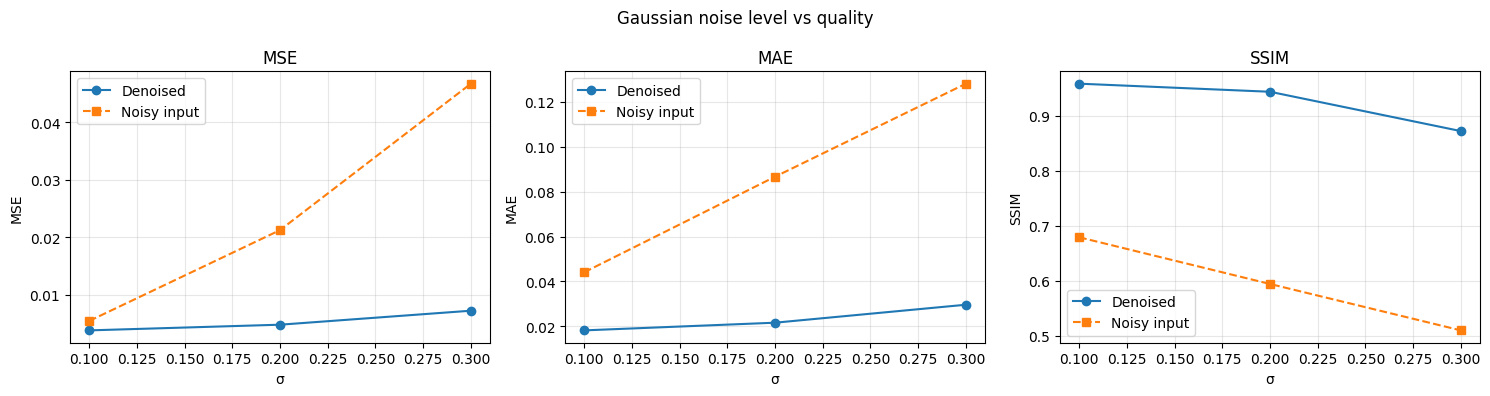

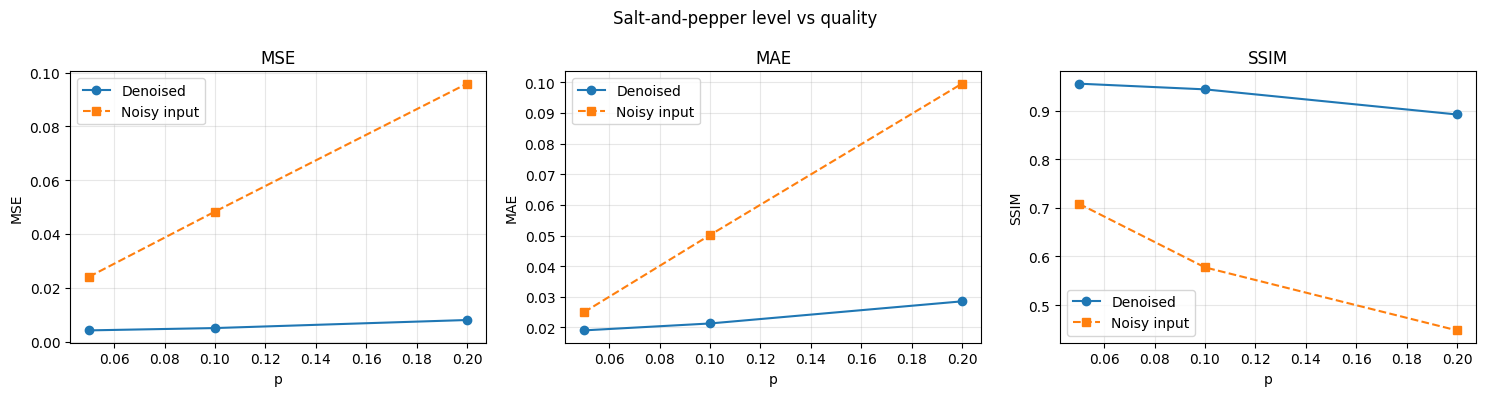

In [13]:
df_g  = sweep(dae_g,  add_gaussian, [0.1, 0.2, 0.3])
df_sp = sweep(dae_sp, add_sp,       [0.05, 0.10, 0.20])
print('Gaussian noise (DAE trained at σ=0.2)')
print(df_g.to_string(index=False))
print('\nSalt-and-pepper noise (DAE trained at p=0.10)')
print(df_sp.to_string(index=False))
plot_sweep(df_g,  'Gaussian noise level vs quality', 'σ')
plot_sweep(df_sp, 'Salt-and-pepper level vs quality', 'p')

row = df_g[df_g['Noise Level'] == 0.2].iloc[0]
results['Denoising CAE'] = (row['MSE'], row['MAE'], row['SSIM'], dae_g.count_params(), t_dae)

In [15]:
class Sampling(layers.Layer):
    def call(self, inputs):
        mu, logvar = inputs
        eps = tf.random.normal(tf.shape(mu))
        return mu + tf.exp(0.5 * logvar) * eps

def build_encoder(d):
    inp = keras.Input((28, 28, 1))
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(inp)
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(16, activation='relu')(x)
    mu = layers.Dense(d, name='mu')(x)
    logvar = layers.Dense(d, name='logvar')(x)
    return keras.Model(inp, [mu, logvar, Sampling()([mu, logvar])], name='encoder')

def build_decoder(d):
    inp = keras.Input((d,))
    x = layers.Dense(7 * 7 * 64, activation='relu')(inp)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
    out = layers.Conv2DTranspose(1, 3, padding='same', activation='sigmoid')(x)
    return keras.Model(inp, out, name='decoder')

class VAE(keras.Model):
    def __init__(self, latent_dim=2, beta=1.0, **kw):
        super().__init__(**kw)
        self.latent_dim, self.beta = latent_dim, beta
        self.encoder, self.decoder = build_encoder(latent_dim), build_decoder(latent_dim)
        self.total_tracker = keras.metrics.Mean(name='loss')
        self.rec_tracker = keras.metrics.Mean(name='reconstruction_loss')
        self.kl_tracker = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.total_tracker, self.rec_tracker, self.kl_tracker]

    def _vae_losses(self, x):
        mu, logvar, z = self.encoder(x)
        xh = self.decoder(z)
        rec = tf.reduce_mean(tf.reduce_sum(keras.losses.binary_crossentropy(x, xh), axis=(1, 2)))
        kl = tf.reduce_mean(-0.5 * tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1))
        return rec + self.beta * kl, rec, kl

    def _vae_update(self, tot, rec, kl):
        self.total_tracker.update_state(tot)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        return {m.name: m.result() for m in self.metrics}

    def train_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        with tf.GradientTape() as tape:
            tot, rec, kl = self._vae_losses(x)
        grads = tape.gradient(tot, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return self._vae_update(tot, rec, kl)

    def test_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        return self._vae_update(*self._vae_losses(x))

def train_vae(d=2, beta=1.0, epochs=EPOCHS, verbose=0):
    v = VAE(d, beta)
    v.compile(optimizer=keras.optimizers.Adam(1e-3))
    t = time.time()
    h = v.fit(x_train, epochs=epochs, batch_size=BATCH, validation_split=0.1, shuffle=True, verbose=verbose)
    return v, h, time.time() - t

def vae_eval(v):
    mu, logvar, _ = v.encoder.predict(x_test, verbose=0)
    xh = v.decoder.predict(mu, verbose=0)
    rec = np.mean(np.sum(keras.losses.binary_crossentropy(x_test, xh).numpy(), axis=(1, 2)))
    kl_dim = -0.5 * np.mean(1 + logvar - mu ** 2 - np.exp(logvar), axis=0)
    ms = get_metrics(x_test, xh)
    return dict(mu=mu, logvar=logvar, xh=xh, rec=rec, kl=kl_dim.sum(), kl_dim=kl_dim, total=rec + v.beta * kl_dim.sum(),
                mse=ms[0], mae=ms[1], ssim=ms[2])

vae, h_vae, t_vae = train_vae(2, 1.0, verbose=2)
ev = vae_eval(vae)

Epoch 1/20
71/71 - 11s - 150ms/step - kl_loss: 1.1845 - loss: 312.0683 - reconstruction_loss: 310.8836 - val_kl_loss: 0.0062 - val_loss: 216.2737 - val_reconstruction_loss: 216.2675
Epoch 2/20
71/71 - 10s - 141ms/step - kl_loss: 0.0320 - loss: 210.8822 - reconstruction_loss: 210.8501 - val_kl_loss: 0.1592 - val_loss: 209.4147 - val_reconstruction_loss: 209.2554
Epoch 3/20
71/71 - 10s - 137ms/step - kl_loss: 1.3106 - loss: 199.8276 - reconstruction_loss: 198.5170 - val_kl_loss: 1.9897 - val_loss: 194.8300 - val_reconstruction_loss: 192.8403
Epoch 4/20
71/71 - 8s - 107ms/step - kl_loss: 1.9743 - loss: 192.2974 - reconstruction_loss: 190.3231 - val_kl_loss: 2.1131 - val_loss: 191.6913 - val_reconstruction_loss: 189.5782
Epoch 5/20
71/71 - 8s - 109ms/step - kl_loss: 2.0944 - loss: 190.1726 - reconstruction_loss: 188.0782 - val_kl_loss: 2.2137 - val_loss: 190.2499 - val_reconstruction_loss: 188.0363
Epoch 6/20
71/71 - 10s - 144ms/step - kl_loss: 2.1879 - loss: 188.7742 - reconstruction_loss

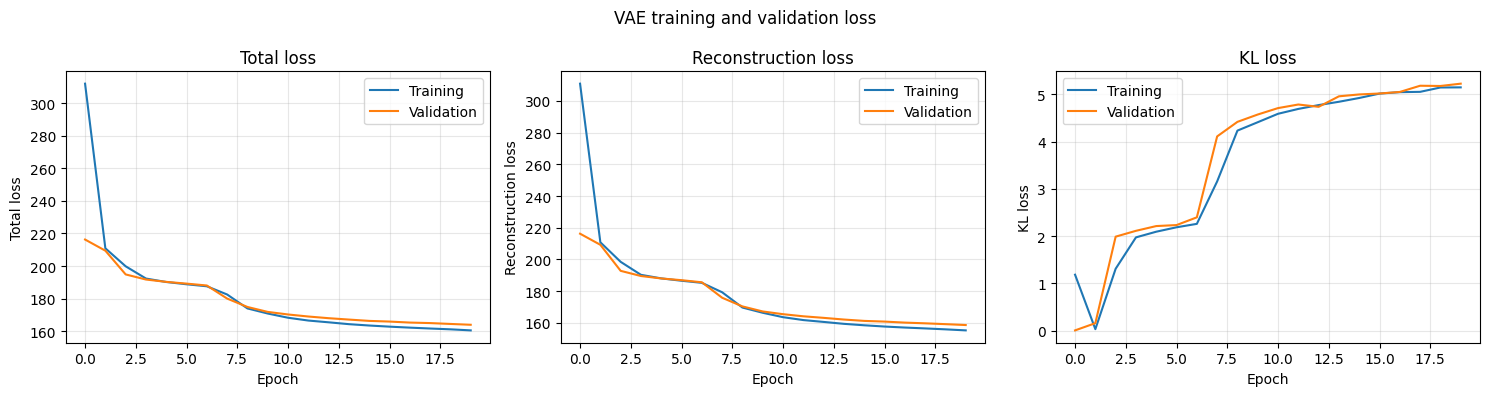

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, (k, nm) in zip(ax, [('loss', 'Total loss'), ('reconstruction_loss', 'Reconstruction loss'), ('kl_loss', 'KL loss')]):
    a.plot(h_vae.history[k], label='Training')
    a.plot(h_vae.history['val_' + k], label='Validation')
    a.set_xlabel('Epoch')
    a.set_ylabel(nm)
    a.set_title(nm)
    a.legend()
    a.grid(alpha=.3)
fig.suptitle('VAE training and validation loss')
plt.tight_layout()
plt.show()

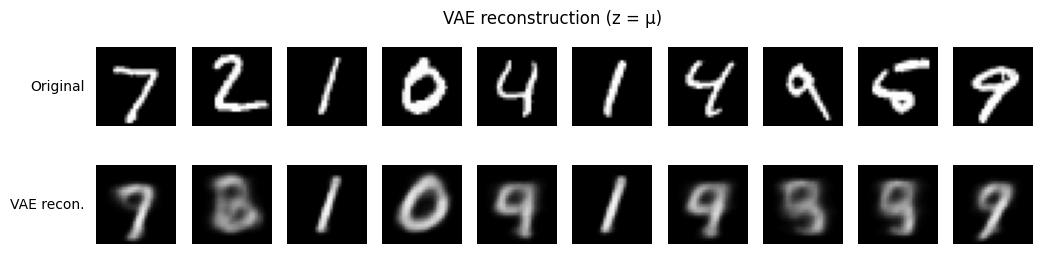

In [17]:
show_grid([x_test[:10], ev['xh'][:10]], ['Original', 'VAE recon.'], title='VAE reconstruction (z = μ)')

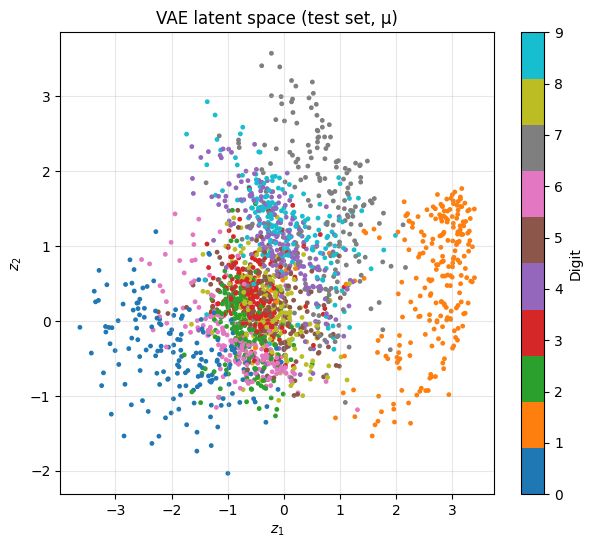

In [18]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(ev['mu'][:, 0], ev['mu'][:, 1], c=y_test, cmap='tab10', s=6)
plt.colorbar(sc, ticks=range(10), label='Digit')
plt.xlabel('$z_1$')
plt.ylabel('$z_2$')
plt.title('VAE latent space (test set, μ)')
plt.grid(alpha=.3)
plt.show()

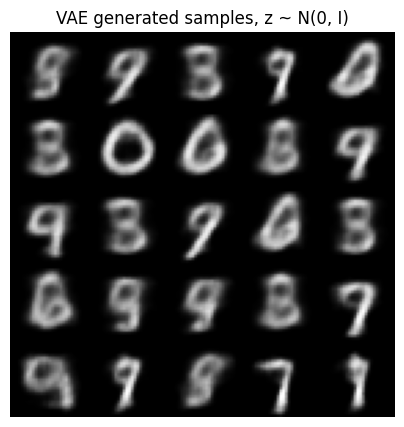

In [19]:
z = np.random.default_rng(0).normal(size=(25, 2)).astype('float32')
plt.figure(figsize=(5, 5))
plt.imshow(tile(vae.decoder.predict(z, verbose=0), 5, 5), cmap='gray')
plt.axis('off')
plt.title('VAE generated samples, z ~ N(0, I)')
plt.show()


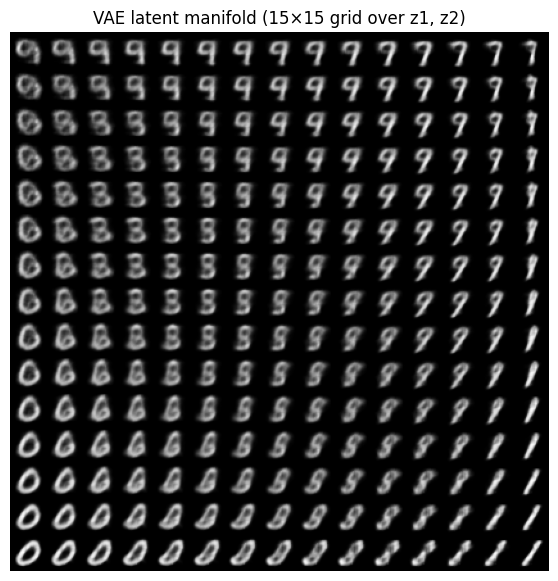

In [20]:
g = norm.ppf(np.linspace(0.05, 0.95, 15))
zg = np.array([[a, b] for b in g[::-1] for a in g], dtype='float32')
plt.figure(figsize=(7, 7))
plt.imshow(tile(vae.decoder.predict(zg, verbose=0), 15, 15), cmap='gray')
plt.axis('off')
plt.title('VAE latent manifold (15×15 grid over z1, z2)')
plt.show()

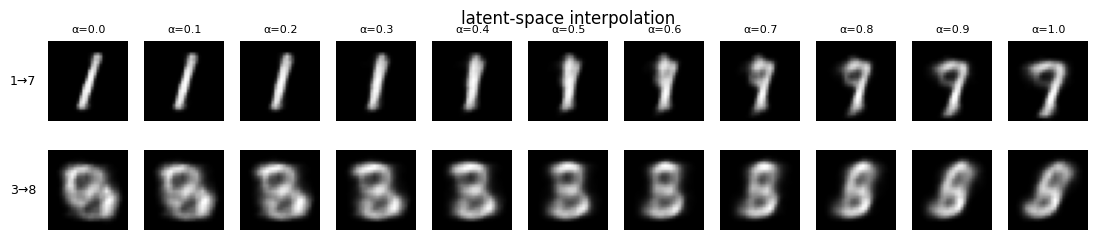

In [21]:
alphas = np.linspace(0, 1, 11)
def interpolate(zA, zB):
    zs = np.array([(1 - a) * zA + a * zB for a in alphas], dtype='float32')
    return vae.decoder.predict(zs, verbose=0)

def show_interp(pairs, title):
    fig, ax = plt.subplots(len(pairs), 11, figsize=(13, 1.3 * len(pairs)))
    ax = np.atleast_2d(ax)
    for r, (nm, zA, zB) in enumerate(pairs):
        for c, im in enumerate(interpolate(zA, zB)):
            ax[r, c].imshow(im.reshape(28, 28), cmap='gray')
            ax[r, c].axis('off')
            if r == 0:
              ax[r, c].set_title(f'α={alphas[c]:.1f}', fontsize=8)
        ax[r, 0].text(-0.15, 0.5, nm, transform=ax[r, 0].transAxes, ha='right', va='center', fontsize=9)
    fig.suptitle(title)
    plt.subplots_adjust(left=0.1)
    plt.show()

iA, iB = np.where(y_test == 1)[0][0], np.where(y_test == 7)[0][0]
iC, iD = np.where(y_test == 3)[0][0], np.where(y_test == 8)[0][0]
show_interp([(f'{y_test[iA]}→{y_test[iB]}', ev['mu'][iA], ev['mu'][iB]),
             (f'{y_test[iC]}→{y_test[iD]}', ev['mu'][iC], ev['mu'][iD])],
            'latent-space interpolation')

FC-AE: mean=0.02043 median=0.01927 std=0.01071 95th pct=0.03938 max=0.06920


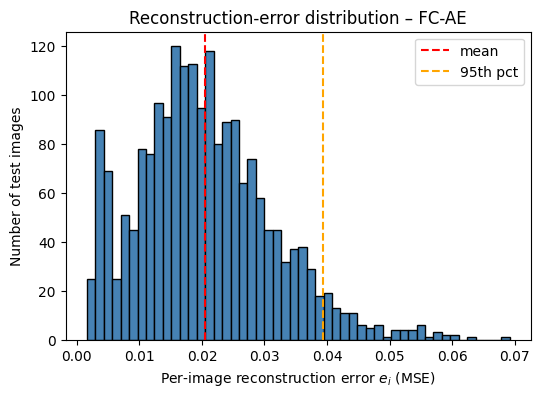

Highest-error samples (index, label, error): [(1782, 8, 0.0692), (1758, 8, 0.06318), (1170, 8, 0.06069), (744, 2, 0.06004), (338, 8, 0.05971)]


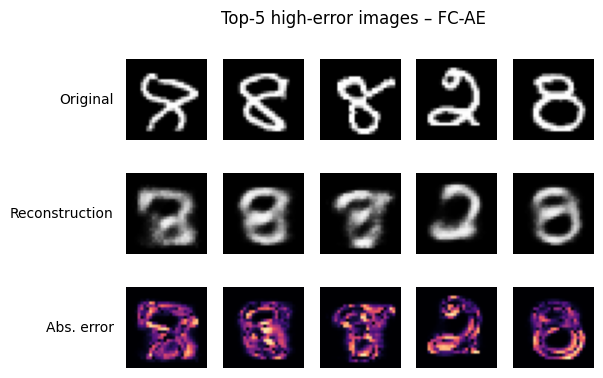

CAE: mean=0.00262 median=0.00239 std=0.00144 95th pct=0.00525 max=0.01219


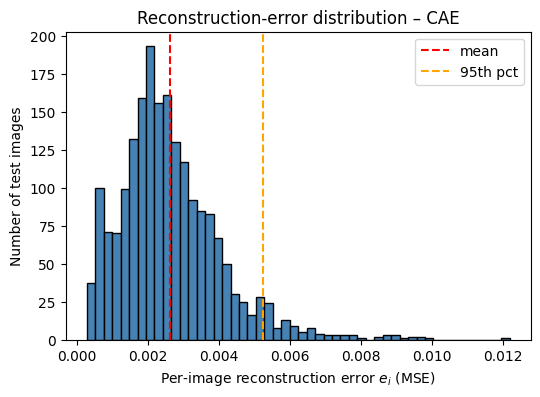

Highest-error samples (index, label, error): [(895, 0, 0.01219), (1982, 6, 0.01002), (431, 8, 0.00979), (1526, 0, 0.00964), (1395, 2, 0.00954)]


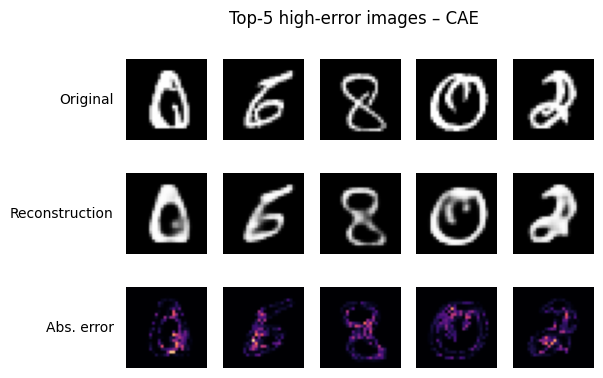

VAE (z=μ): mean=0.04589 median=0.04628 std=0.01901 95th pct=0.07703 max=0.11196


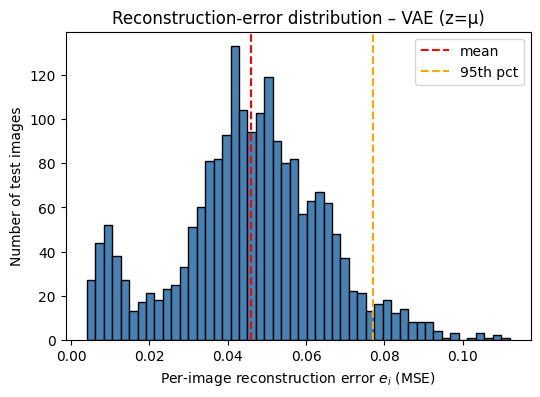

Highest-error samples (index, label, error): [(864, 8, 0.11196), (998, 8, 0.10968), (810, 7, 0.10826), (1790, 2, 0.10704), (1352, 2, 0.10419)]


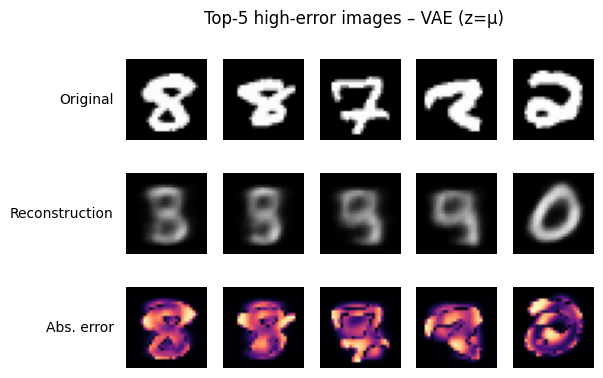

In [22]:
error_distribution(x_test, xh_fc, 'FC-AE')
error_distribution(x_test, xh_cae, 'CAE')
error_distribution(x_test, ev['xh'], 'VAE (z=μ)')

 Latent Dimension     MSE    SSIM  Parameters
                2 0.04538 0.45377      210130
                8 0.02662 0.68595      210520
               16 0.02137 0.74386      211040
               32 0.01993 0.76512      212080


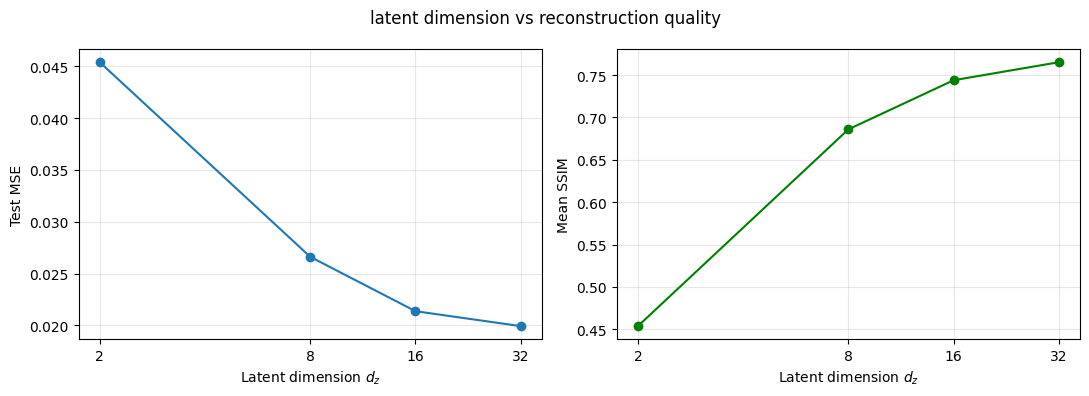

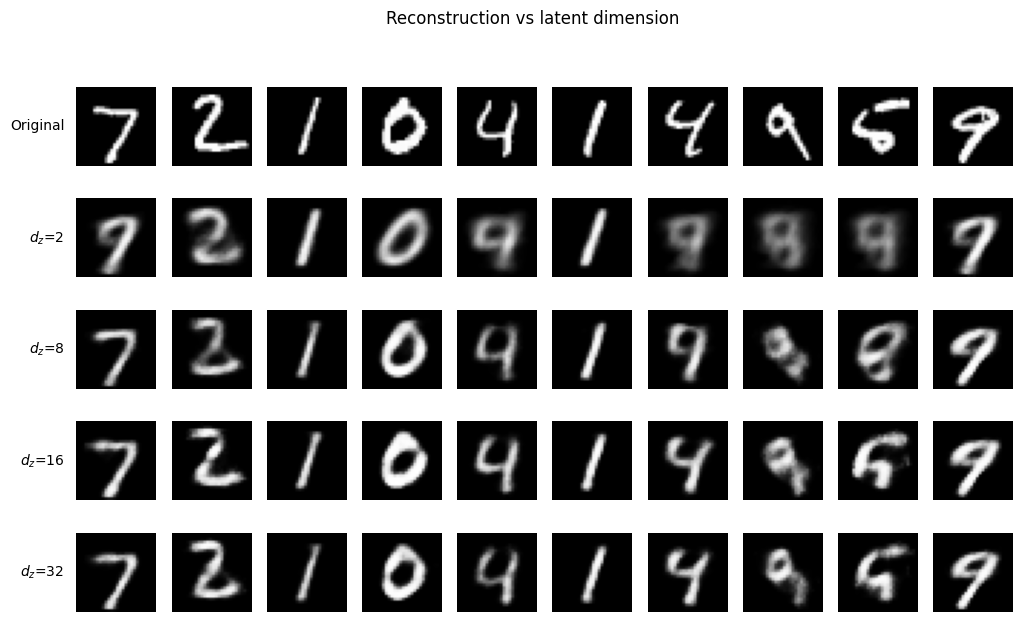

In [23]:
rows, recs = [], []
for d in [2, 8, 16, 32]:
    mdl = build_fc_ae(d); _, _ = fit_ae(mdl, x_train_f, x_train_f, verbose=0)
    xr = mdl.predict(x_test_f, verbose=0)
    mse_, mae_, ssim_ = get_metrics(x_test_f, xr)
    rows.append({'Latent Dimension': d, 'MSE': mse_, 'SSIM': ssim_, 'Parameters': mdl.count_params()})
    recs.append(xr[:10])
df_lat = pd.DataFrame(rows)
print(df_lat.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(df_lat['Latent Dimension'], df_lat['MSE'], 'o-'); ax[0].set_ylabel('Test MSE')
ax[1].plot(df_lat['Latent Dimension'], df_lat['SSIM'], 'o-', color='g'); ax[1].set_ylabel('Mean SSIM')
for a in ax:
  a.set_xlabel('Latent dimension $d_z$')
  a.set_xscale('log', base=2)
  a.set_xticks([2, 8, 16, 32])
  a.set_xticklabels([2, 8, 16, 32])
  a.grid(alpha=.3)
fig.suptitle('latent dimension vs reconstruction quality')
plt.tight_layout()
plt.show()
show_grid([x_test_f[:10]] + recs, ['Original'] + [f'$d_z$={d}' for d in [2, 8, 16, 32]], title='Reconstruction vs latent dimension')

In [25]:
vm = (ev['mse'], ev['mae'], ev['ssim'], vae.encoder.count_params() + vae.decoder.count_params(), t_vae)
results['VAE'] = vm
df_res = pd.DataFrame(results, index=['MSE', 'MAE', 'SSIM', 'Parameters', 'Time (s)']).T
print('Reconstruction comparison'); print(df_res.loc[['FC Autoencoder', 'Conv. Autoencoder', 'Denoising CAE'], ['MSE', 'MAE', 'SSIM', 'Parameters']].to_string())
print('\nVAE metrics')
print(pd.DataFrame({'VAE Metric': ['Reconstruction Loss', 'KL Loss', 'Total Loss', 'Test MSE', 'Test MAE', 'Mean SSIM'],
                    'Value': [ev['rec'], ev['kl'], ev['total'], ev['mse'], ev['mae'], ev['ssim']]}).to_string(index=False))
print('\nConsolidated results')
print(df_res.to_string())

Reconstruction comparison
                      MSE     MAE    SSIM   Parameters
FC Autoencoder    0.02043 0.05521 0.75860 211040.00000
Conv. Autoencoder 0.00262 0.01510 0.97372  74497.00000
Denoising CAE     0.00479 0.02164 0.94371  74497.00000

VAE metrics
         VAE Metric     Value
Reconstruction Loss 153.61421
            KL Loss   5.20904
         Total Loss 158.82324
           Test MSE   0.04589
           Test MAE   0.10827
          Mean SSIM   0.45395

Consolidated results
                      MSE     MAE    SSIM   Parameters  Time (s)
FC Autoencoder    0.02043 0.05521 0.75860 211040.00000  12.89587
Conv. Autoencoder 0.00262 0.01510 0.97372  74497.00000 356.99474
Denoising CAE     0.00479 0.02164 0.94371  74497.00000 395.91276
VAE               0.04589 0.10827 0.45395 134165.00000 179.51260


 Latent Dimension     MSE     MAE    SSIM  Parameters
                4 0.03413 0.08059 0.63230       65797
                8 0.02058 0.05374 0.76959       90889
               16 0.01093 0.03428 0.88118      141073
               32 0.00629 0.02427 0.93220      241441


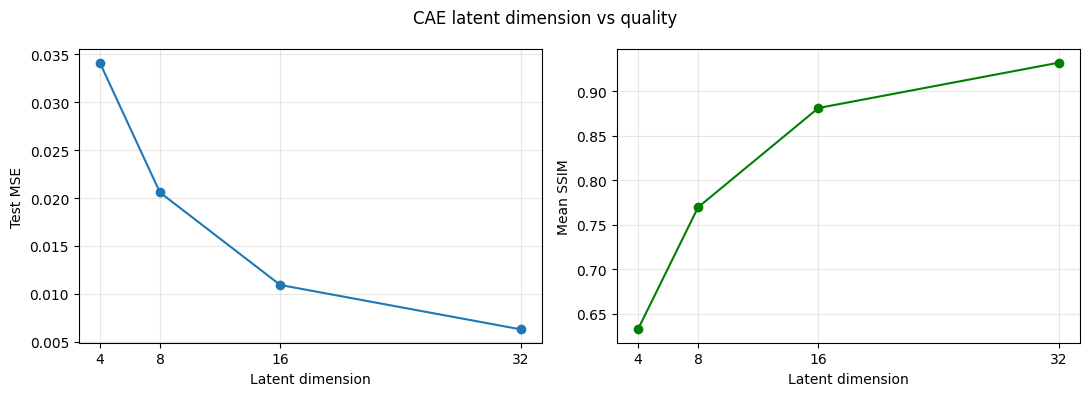

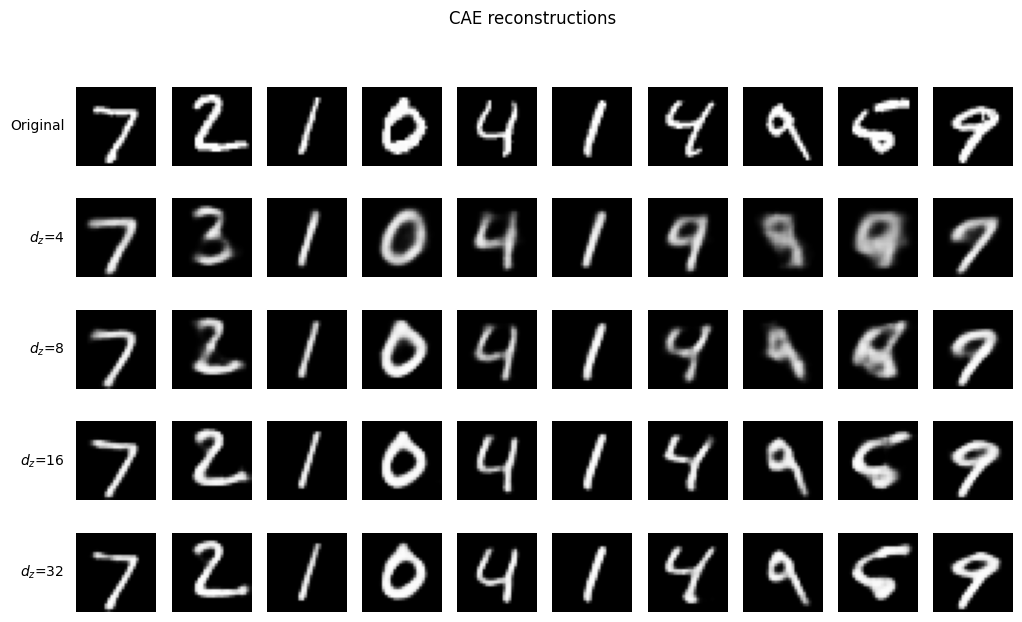

In [26]:
def build_cae_latent(d):
    inp = keras.Input((28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Flatten()(x)
    z = layers.Dense(d, name='latent')(x)
    x = layers.Dense(7 * 7 * 64, activation='relu')(z)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)
    return keras.Model(inp, out, name=f'cae_lat_{d}')

rows, recs = [], []
for d in [4, 8, 16, 32]:
    mdl = build_cae_latent(d); fit_ae(mdl, x_train, x_train, verbose=0)
    xr = mdl.predict(x_test, verbose=0); a, b, c = get_metrics(x_test, xr)
    rows.append({'Latent Dimension': d, 'MSE': a, 'MAE': b, 'SSIM': c, 'Parameters': mdl.count_params()}); recs.append(xr[:10])
df_e1 = pd.DataFrame(rows); print(df_e1.to_string(index=False))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(df_e1['Latent Dimension'], df_e1['MSE'], 'o-')
ax[0].set_ylabel('Test MSE')
ax[1].plot(df_e1['Latent Dimension'], df_e1['SSIM'], 'o-', color='g')
ax[1].set_ylabel('Mean SSIM')
for a in ax:
  a.set_xlabel('Latent dimension')
  a.set_xticks([4, 8, 16, 32])
  a.grid(alpha=.3)
fig.suptitle('CAE latent dimension vs quality')
plt.tight_layout()
plt.show()
show_grid([x_test[:10]] + recs, ['Original'] + [f'$d_z$={d}' for d in [4, 8, 16, 32]], title='CAE reconstructions')

                        Model         Test noise     MSE     MAE    SSIM
DAE trained on Gaussian σ=0.2     Gaussian σ=0.2 0.00479 0.02164 0.94371
DAE trained on Gaussian σ=0.2 Salt&Pepper p=0.10 0.00698 0.02690 0.88748
    DAE trained on S&P p=0.10     Gaussian σ=0.2 0.01132 0.04529 0.71306
    DAE trained on S&P p=0.10 Salt&Pepper p=0.10 0.00501 0.02131 0.94375


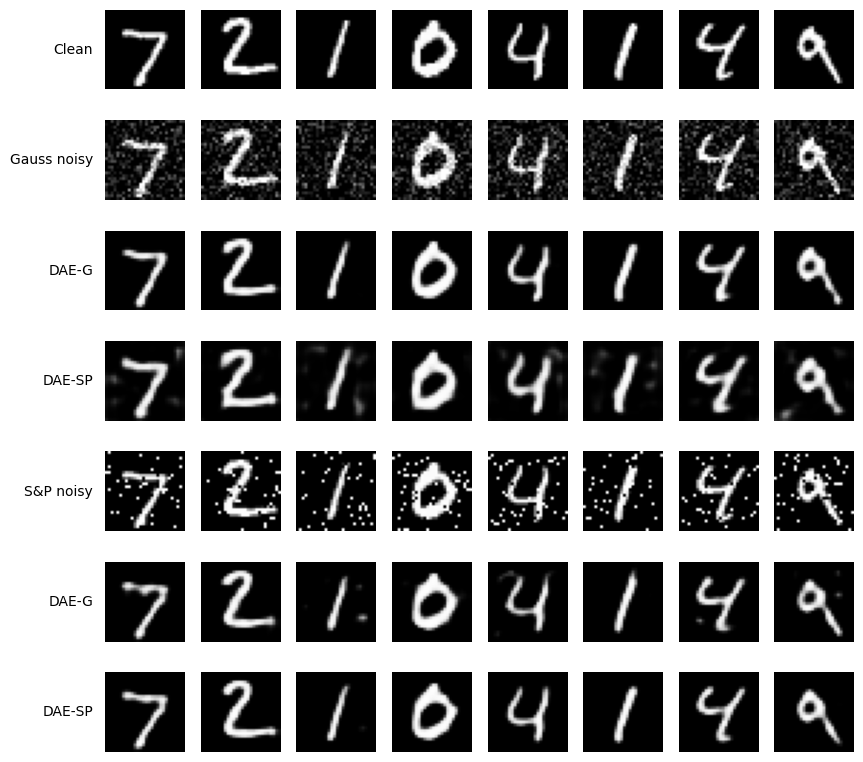

In [27]:
tests = {'Gaussian σ=0.2': add_gaussian(x_test, 0.2, seed=123), 'Salt&Pepper p=0.10': add_sp(x_test, 0.10, seed=123)}
rows = []
for mname, mdl in [('DAE trained on Gaussian σ=0.2', dae_g), ('DAE trained on S&P p=0.10', dae_sp)]:
    for tname, xn in tests.items():
        a, b, c = get_metrics(x_test, mdl.predict(xn, verbose=0))
        rows.append({'Model': mname, 'Test noise': tname, 'MSE': a, 'MAE': b, 'SSIM': c})
print(pd.DataFrame(rows).to_string(index=False))
show_grid([x_test[:8], tests['Gaussian σ=0.2'][:8], dae_g.predict(tests['Gaussian σ=0.2'][:8], verbose=0), dae_sp.predict(tests['Gaussian σ=0.2'][:8], verbose=0),
           tests['Salt&Pepper p=0.10'][:8], dae_g.predict(tests['Salt&Pepper p=0.10'][:8], verbose=0), dae_sp.predict(tests['Salt&Pepper p=0.10'][:8], verbose=0)],
          ['Clean', 'Gauss noisy', 'DAE-G', 'DAE-SP', 'S&P noisy', 'DAE-G', 'DAE-SP'], n=8)

In [28]:
dae_01, _, _ = train_dae(add_gaussian, 0.1); dae_03, _, _ = train_dae(add_gaussian, 0.3)
rows = []
for nm, mdl in [('trained σ=0.1', dae_01), ('trained σ=0.2', dae_g), ('trained σ=0.3', dae_03)]:
    r = {'Model': nm}
    for s in [0.1, 0.2, 0.3]:
        r[f'SSIM @ test σ={s}'] = get_metrics(x_test, mdl.predict(add_gaussian(x_test, s, seed=123), verbose=0))[2]
    rows.append(r)
print(pd.DataFrame(rows).to_string(index=False))

        Model  SSIM @ test σ=0.1  SSIM @ test σ=0.2  SSIM @ test σ=0.3
trained σ=0.1            0.96294            0.88348            0.69630
trained σ=0.2            0.95845            0.94371            0.87211
trained σ=0.3            0.95098            0.94097            0.91712


            Decoder     MSE     MAE    SSIM  Parameters  Time (s)
UpSampling2D + Conv 0.00262 0.01510 0.97372       74497 356.99474
    Conv2DTranspose 0.00244 0.01452 0.97469       74497 179.35877


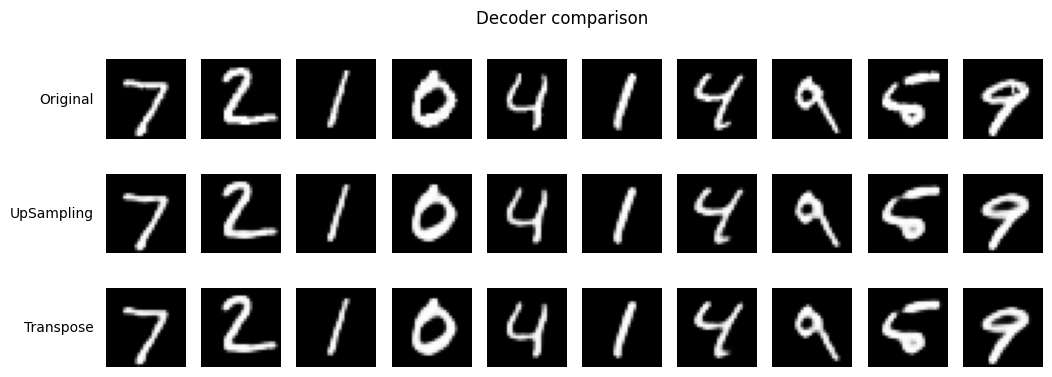

In [29]:
cae_t = build_cae('transpose'); _, t_cae_t = fit_ae(cae_t, x_train, x_train, verbose=0)
xh_t = cae_t.predict(x_test, verbose=0)
mt = get_metrics(x_test, xh_t)
print(pd.DataFrame({'Decoder': ['UpSampling2D + Conv', 'Conv2DTranspose'],
                    'MSE': [m_cae[0], mt[0]], 'MAE': [m_cae[1], mt[1]], 'SSIM': [m_cae[2], mt[2]],
                    'Parameters': [cae.count_params(), cae_t.count_params()], 'Time (s)': [t_cae, t_cae_t]}).to_string(index=False))
show_grid([x_test[:10], xh_cae[:10], xh_t[:10]], ['Original', 'UpSampling', 'Transpose'], title='Decoder comparison')

 Latent dim  Recon loss  KL loss     Total     MSE    SSIM
          2   153.61421  5.20904 158.82324 0.04589 0.45395
          8   158.72047  5.81960 164.54007 0.04818 0.42785


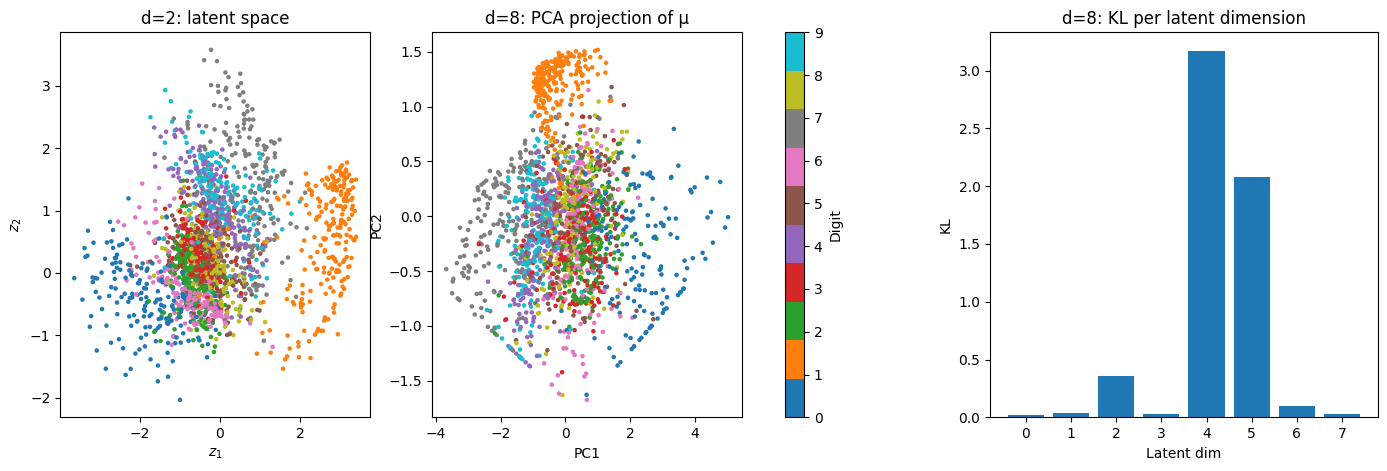

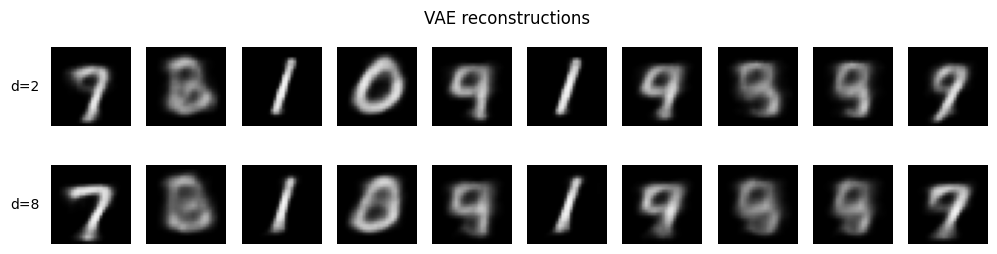

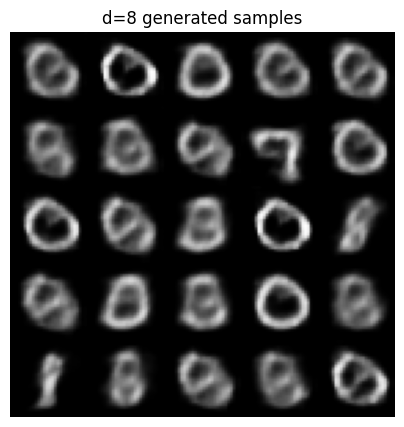

In [30]:
vae8, h_vae8, t_vae8 = train_vae(8, 1.0); ev8 = vae_eval(vae8)
print(pd.DataFrame({'Latent dim': [2, 8], 'Recon loss': [ev['rec'], ev8['rec']], 'KL loss': [ev['kl'], ev8['kl']],
                    'Total': [ev['total'], ev8['total']], 'MSE': [ev['mse'], ev8['mse']], 'SSIM': [ev['ssim'], ev8['ssim']]}).to_string(index=False))

fig, ax = plt.subplots(1, 3, figsize=(17, 5))
ax[0].scatter(ev['mu'][:, 0], ev['mu'][:, 1], c=y_test, cmap='tab10', s=5); ax[0].set_title('d=2: latent space')
ax[0].set_xlabel('$z_1$')
ax[0].set_ylabel('$z_2$')
p = PCA(2).fit_transform(ev8['mu'])
sc = ax[1].scatter(p[:, 0], p[:, 1], c=y_test, cmap='tab10', s=5)
ax[1].set_title('d=8: PCA projection of μ')
ax[1].set_xlabel('PC1')
ax[1].set_ylabel('PC2')
ax[2].bar(np.arange(8), ev8['kl_dim'])
ax[2].set_title('d=8: KL per latent dimension')
ax[2].set_xlabel('Latent dim')
ax[2].set_ylabel('KL')
fig.colorbar(sc, ax=ax[:2], ticks=range(10), label='Digit')
plt.show()
z8 = np.random.default_rng(0).normal(size=(25, 8)).astype('float32')
show_grid([ev['xh'][:10], ev8['xh'][:10]], ['d=2', 'd=8'], title='VAE reconstructions')
plt.figure(figsize=(5, 5))
plt.imshow(tile(vae8.decoder.predict(z8, verbose=0), 5, 5), cmap='gray')
plt.axis('off')
plt.title('d=8 generated samples')
plt.show()

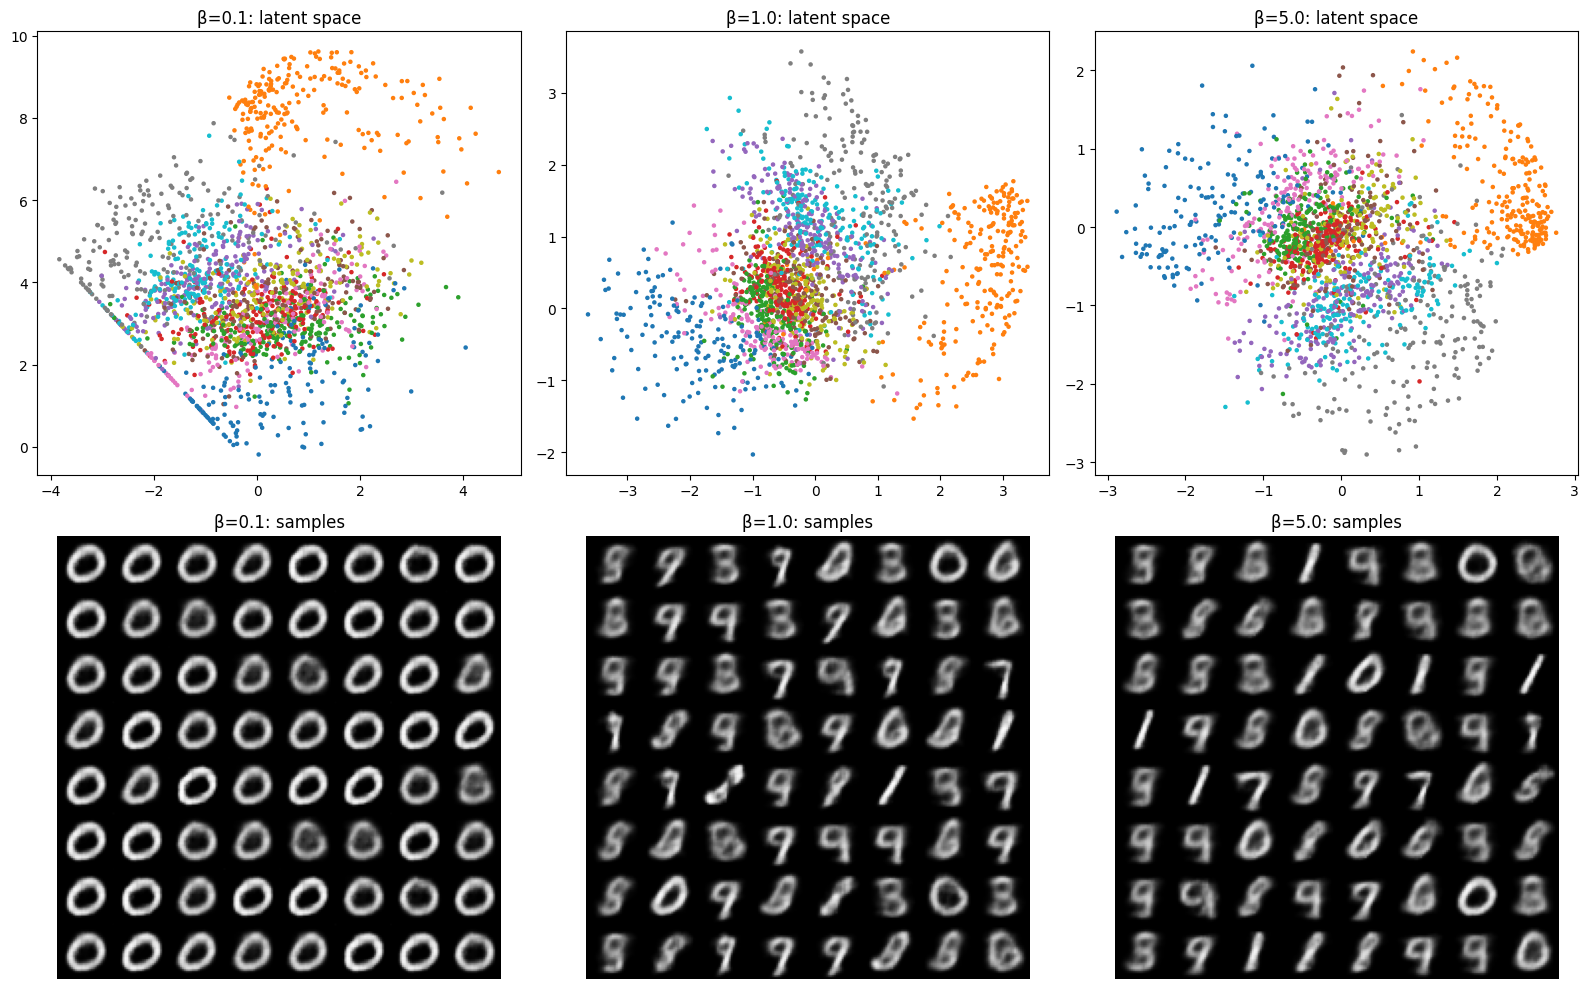

      β  Recon loss  KL loss     MSE    SSIM
0.10000   160.14459 15.17148 0.04891 0.41747
1.00000   153.61421  5.20904 0.04589 0.45395
5.00000   154.50043  3.08957 0.04621 0.44215


In [31]:
betas = [0.1, 1.0, 5.0]
vaes = {1.0: (vae, ev)}
for b in [0.1, 5.0]:
    v, _, _ = train_vae(2, b); vaes[b] = (v, vae_eval(v))
rows = []
fig, ax = plt.subplots(2, 3, figsize=(16, 10))
for j, b in enumerate(betas):
    v, e = vaes[b]
    rows.append({'β': b, 'Recon loss': e['rec'], 'KL loss': e['kl'], 'MSE': e['mse'], 'SSIM': e['ssim']})
    ax[0, j].scatter(e['mu'][:, 0], e['mu'][:, 1], c=y_test, cmap='tab10', s=5)
    ax[0, j].set_title(f'β={b}: latent space')
    zz = np.random.default_rng(0).normal(size=(64, 2)).astype('float32')
    ax[1, j].imshow(tile(v.decoder.predict(zz, verbose=0), 8, 8), cmap='gray')
    ax[1, j].axis('off')
    ax[1, j].set_title(f'β={b}: samples')
plt.tight_layout()
plt.show()
print(pd.DataFrame(rows).to_string(index=False))

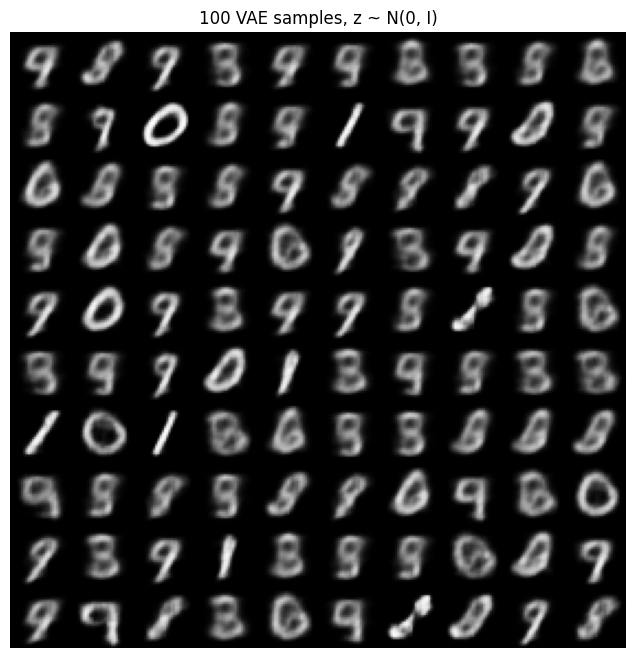

In [32]:
zz = np.random.default_rng(1).normal(size=(100, 2)).astype('float32')
plt.figure(figsize=(8, 8))
plt.imshow(tile(vae.decoder.predict(zz, verbose=0), 10, 10), cmap='gray')
plt.axis('off')
plt.title('100 VAE samples, z ~ N(0, I)')
plt.show()

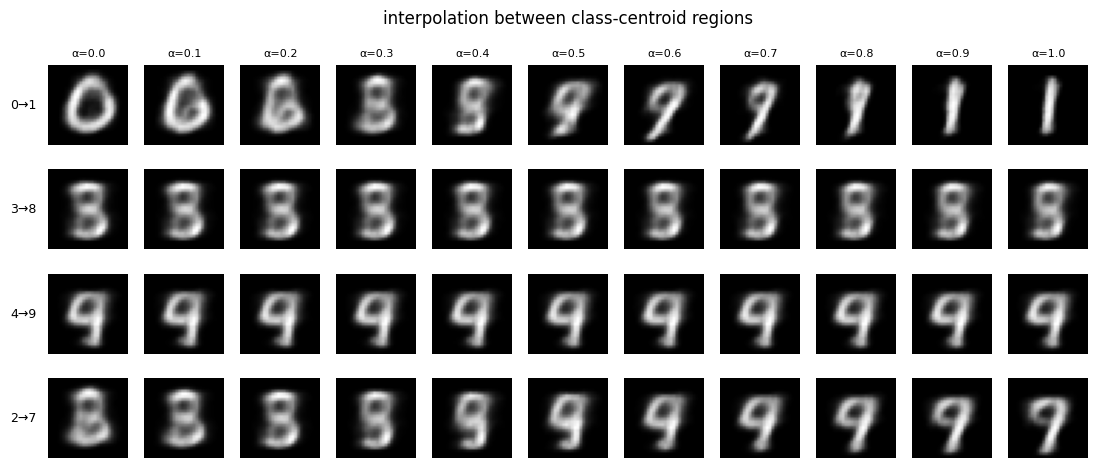

In [33]:
cent = {k: ev['mu'][y_test == k].mean(0) for k in range(10)}
show_interp([(f'{a}→{b}', cent[a], cent[b]) for a, b in [(0, 1), (3, 8), (4, 9), (2, 7)]],
            'interpolation between class-centroid regions')